# 03 — Merge, normalisation, integration and clustering
Input: 90,502 singlets from notebook 02 (10 samples).
Paper: log-normalisation, Seurat integration, clustering at resolution 0.3, UMAP.
Integration method is set in Step 9.1 (RPCA on 12 GB PC; CCA planned on 64 GB machine).

## Step 9.1 — Setup and choose integration method

In [2]:
suppressPackageStartupMessages({
  library(Seurat); library(tidyverse); library(patchwork)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)
options(future.globals.maxSize = Inf)

integration_method <- "RPCA"   # change to "CCA" on the high-RAM machine
m <- tolower(integration_method)

In [3]:
## Step 9.2 — Load singlets and merge into one object

In [4]:
objs <- readRDS(file.path(proj, "results/objects/02_objs_singlets.rds"))
obj  <- merge(objs[[1]], y = objs[-1], add.cell.ids = names(objs))
rm(objs); gc()

obj <- JoinLayers(obj)
obj[["RNA"]] <- split(obj[["RNA"]], f = obj$sample)

obj@meta.data <- obj@meta.data |>
  select(-starts_with("pANN"), -starts_with("DF.classifications"),
         -any_of(c("RNA_snn_res.0.3", "seurat_clusters")))
obj
table(obj$sample)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3864503,206.4,6982888,373.0,6982888,373.0
Vcells,284240224,2168.6,786362808,5999.5,786338390,5999.3


An object of class Seurat 
36601 features across 90502 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 10 layers present: counts.HD1, counts.HD2, counts.P1, counts.P2, counts.P3, counts.P4, counts.P5, counts.P6, counts.P7, counts.P8


  HD1   HD2    P1    P2    P3    P4    P5    P6    P7    P8 
 7121 10920  9284 12512 11682  9625  2765  9055  8693  8845 

## Step 9.2b — Checkpoint: save the merged object

In [5]:
saveRDS(obj, file.path(proj, "results/objects/03a_merged_split.rds"), compress = FALSE)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3892191,207.9,6982888,373.0,6982888,373.0
Vcells,282310755,2153.9,1130370756,8624.1,1399368720,10676.4


In [ ]:
## Step 9.3 — Normalise, variable genes, scale, PCA

Normalised

Variable features done

Scaled

PCA done



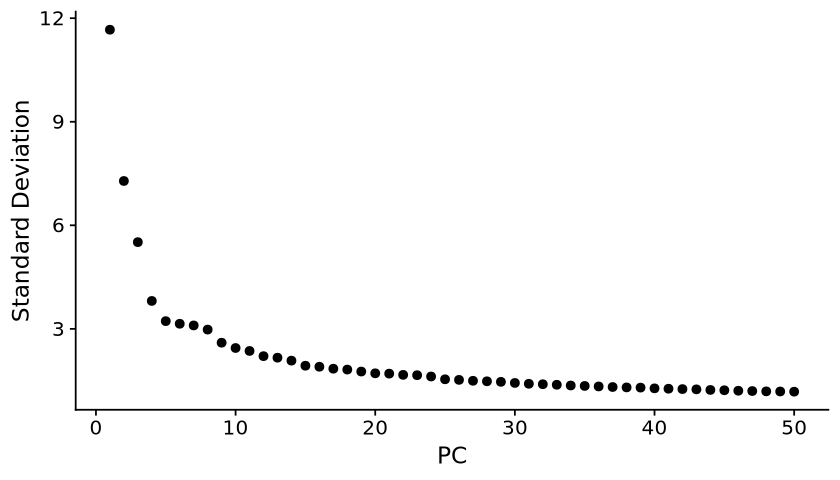

In [6]:
obj <- NormalizeData(obj, verbose = FALSE); invisible(gc())
message("Normalised")
obj <- FindVariableFeatures(obj, nfeatures = 2000, verbose = FALSE); invisible(gc())
message("Variable features done")
obj <- ScaleData(obj, verbose = FALSE); invisible(gc())
message("Scaled")
obj <- RunPCA(obj, npcs = 50, verbose = FALSE); invisible(gc())
message("PCA done")

options(repr.plot.width = 7, repr.plot.height = 4)
elbow <- ElbowPlot(obj, ndims = 50)
elbow
ggsave(file.path(proj, "figures/trackB/03_elbow_plot.png"), elbow, width = 7, height = 4, dpi = 150)

### PC selection
- Elbow: steep drop PCs 1–4, shoulder 5–8, gradual decline to ~20, flat from ~25–30.
- Using 30 PCs for neighbours, clustering, UMAP and integration (paper does not report this).
  Slightly past the elbow to retain rare populations (e.g. pDCs, Tregs).

In [ ]:
## Step 9.4 — Unintegrated UMAP (to see the batch effect)

In [7]:
dims <- 1:30
obj <- obj |>
  FindNeighbors(dims = dims, reduction = "pca", verbose = FALSE) |>
  FindClusters(resolution = 0.3, cluster.name = "clusters_unintegrated", verbose = FALSE) |>
  RunUMAP(dims = dims, reduction = "pca", reduction.name = "umap.unintegrated", verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [ ]:
## Step 9.5 — Integration

In [9]:
library(future)
plan("sequential")                      # run in this R session only — no data copies
options(future.globals.maxSize = Inf)   # remove the size check (safe in sequential mode)

int_fun <- switch(integration_method, RPCA = RPCAIntegration, CCA = CCAIntegration)
int_red <- paste0("integrated.", m)

obj <- IntegrateLayers(obj, method = int_fun, orig.reduction = "pca",
                       new.reduction = int_red, verbose = FALSE)

In [ ]:
- Note: IntegrateLayers failed with a future.globals.maxSize error (15.88 GiB > 8 GiB limit).
  Fixed with plan("sequential") + future.globals.maxSize = Inf; no parallel copies are made.

In [ ]:
## Step 9.6 — Cluster and UMAP on the integrated data

In [10]:
obj <- FindNeighbors(obj, reduction = int_red, dims = dims, verbose = FALSE); invisible(gc())
message("Neighbours done")
obj <- FindClusters(obj, resolution = 0.3, cluster.name = paste0("clusters_", m), verbose = FALSE)
message("Clusters done")
obj <- RunUMAP(obj, reduction = int_red, dims = dims,
               reduction.name = paste0("umap.", m), verbose = FALSE); invisible(gc())
message("UMAP done")

obj[["RNA"]]$scale.data <- NULL; invisible(gc())   # no longer needed after integration
obj <- JoinLayers(obj); invisible(gc())
message("Layers joined")

table(obj[[paste0("clusters_", m)]])

Neighbours done

Clusters done

UMAP done

Layers joined



clusters_rpca
    0     1     2     3     4     5     6     7     8     9    10    11    12 
24806 12881 12787  9755  8626  8383  3505  2721  2195  1913  1217   900   453 
   13    14 
  268    92 

In [ ]:
## Step 9.7 — Before vs after integration

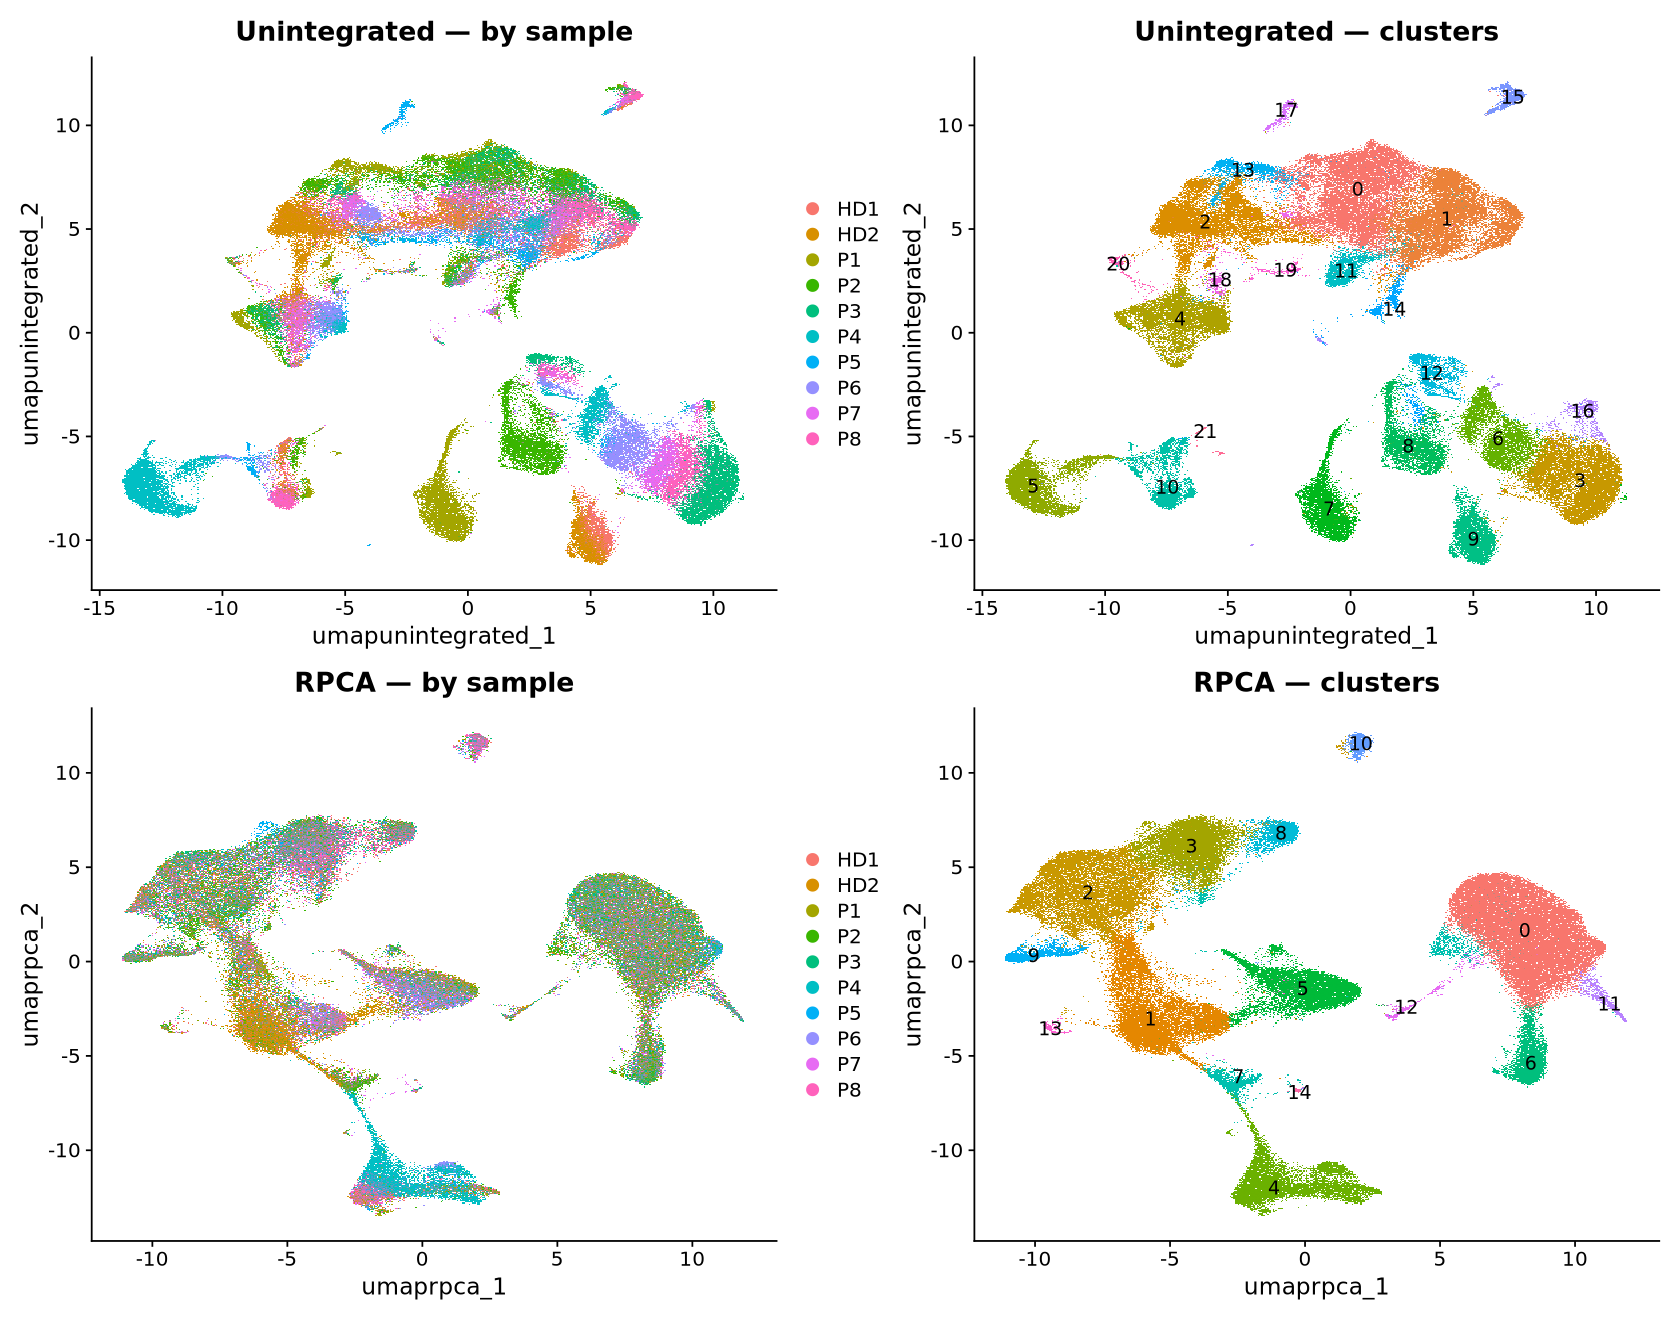

In [11]:
options(repr.plot.width = 14, repr.plot.height = 11)
p <- (DimPlot(obj, reduction = "umap.unintegrated", group.by = "sample", raster = TRUE) +
        ggtitle("Unintegrated — by sample") |
      DimPlot(obj, reduction = "umap.unintegrated", group.by = "clusters_unintegrated",
              label = TRUE, raster = TRUE) + NoLegend() + ggtitle("Unintegrated — clusters")) /
     (DimPlot(obj, reduction = paste0("umap.", m), group.by = "sample", raster = TRUE) +
        ggtitle(paste(integration_method, "— by sample")) |
      DimPlot(obj, reduction = paste0("umap.", m), group.by = paste0("clusters_", m),
              label = TRUE, raster = TRUE) + NoLegend() + ggtitle(paste(integration_method, "— clusters")))
p
ggsave(file.path(proj, "figures/trackB", paste0("03_umap_before_after_", m, ".png")),
       p, width = 14, height = 11, dpi = 150)

In [ ]:
## Step 9.8 — Cluster composition by sample

In [12]:
comp <- table(obj[[paste0("clusters_", m)]][[1]], obj$sample)
comp_pct <- round(100 * prop.table(comp, margin = 1), 1)
comp_pct
write.csv(as.data.frame.matrix(comp),
          file.path(proj, "results/tables", paste0("03_cluster_by_sample_counts_", m, ".csv")))

    
      HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  0   5.7  8.6 15.1 12.9 21.2  6.6  0.8 12.9  7.8  8.5
  1   8.0 39.1 10.7 10.1  4.6  1.3  3.4  9.1  8.8  5.0
  2  12.5  9.3  9.5 19.7 14.9  5.2  3.8  8.6 10.3  6.1
  3  14.2  2.5  3.1 16.1  9.8  8.8  7.7  6.8 13.8 17.3
  4   4.9  3.6  4.1  4.7  0.3 57.5  4.4  5.1  2.6 13.0
  5   4.4 15.4  9.1  7.8 10.6  7.5  1.9 18.8 16.4  8.0
  6   2.1  2.8 19.5 22.7 20.1  4.0  0.7 10.5  9.1  8.5
  7   5.8  9.8 12.6 39.0  6.5  7.2  2.2  2.3 11.7  3.1
  8  18.1  1.7  1.8 15.8 18.0  4.5  6.2  5.3  3.2 25.4
  9   6.2  6.5 12.2 22.2 14.6  7.4  2.8  7.6 12.5  8.1
  10  4.4  3.6  2.1  7.6  6.5  4.8  5.2  2.9 14.1 49.1
  11  4.8  4.8  8.1  8.1 32.0  4.6  1.6 12.9 12.8 10.4
  12  6.6 15.7 12.8  6.8 24.1  3.8  1.1 11.3 14.3  3.5
  13 12.7 13.1 22.4 17.2  9.3  0.7  2.6  6.7  7.8  7.5
  14  6.5 17.4  6.5  5.4 12.0  1.1  3.3  1.1 46.7  0.0

## Step 9.8b — Enrichment of each sample per cluster (observed / expected)

In [13]:
expected <- prop.table(table(obj$sample))
oe <- round(sweep(prop.table(comp, margin = 1), 2, expected, "/"), 2)
oe
write.csv(as.data.frame.matrix(oe),
          file.path(proj, "results/tables", paste0("03_cluster_sample_OE_", m, ".csv")))

    
      HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  0  0.72 0.71 1.47 0.93 1.64 0.62 0.26 1.28 0.81 0.87
  1  1.01 3.24 1.05 0.73 0.35 0.12 1.10 0.91 0.91 0.52
  2  1.59 0.77 0.93 1.43 1.15 0.49 1.24 0.86 1.07 0.63
  3  1.80 0.20 0.30 1.16 0.76 0.83 2.52 0.68 1.44 1.77
  4  0.62 0.29 0.40 0.34 0.02 5.41 1.43 0.51 0.27 1.33
  5  0.56 1.27 0.89 0.56 0.82 0.71 0.62 1.88 1.71 0.82
  6  0.26 0.23 1.90 1.64 1.56 0.38 0.21 1.05 0.95 0.87
  7  0.73 0.81 1.23 2.82 0.50 0.68 0.71 0.23 1.21 0.31
  8  2.30 0.14 0.17 1.14 1.40 0.42 2.03 0.53 0.33 2.60
  9  0.78 0.54 1.19 1.61 1.13 0.69 0.91 0.76 1.30 0.82
  10 0.55 0.30 0.20 0.55 0.50 0.45 1.69 0.29 1.46 5.02
  11 0.61 0.40 0.79 0.59 2.48 0.43 0.51 1.29 1.33 1.07
  12 0.84 1.30 1.25 0.49 1.86 0.35 0.36 1.13 1.49 0.36
  13 1.61 1.08 2.18 1.24 0.72 0.07 0.85 0.67 0.82 0.76
  14 0.83 1.44 0.64 0.39 0.93 0.10 1.07 0.11 4.87 0.00

### Integration assessment (RPCA)
- Before integration: strong batch effect, many sample-specific islands (22 clusters).
- After RPCA: 15 clusters; most well mixed. No single-sample cluster.
- Patient-enriched clusters (~5x expected share): 4 (P4, 57.5%), 10 (P8, 49.1%), 14 (P7, 46.7%; 92 cells).
  Likely genuine compositional differences; to confirm with markers during annotation.
- P5 depleted in clusters 0 and 6 (0.8%, 0.7% vs 3.1% expected); if myeloid, consistent with
  monocyte loss in a low-viability sample.
  - O/E ratios confirm patient-enriched clusters: 4 (P4 5.4x), 10 (P8 5.0x), 14 (P7 4.9x), 1 (HD2 3.2x), 7 (P2 2.8x).
- Clusters 0 and 6 enriched in P1–P3 (1.5–1.9x), depleted in P4, P5, HDs -> possibly larger myeloid compartment in high-IRC patients (to confirm after annotation).
- Clusters 3 and 8 enriched in HD1, P5, P8 (1.8–2.6x); not group-specific.
- Caution: proportions are compositional; P5's myeloid loss inflates its O/E in other clusters.

In [ ]:
## Step 9.9 — Save the integrated object

In [14]:
obj <- DietSeurat(obj, layers = c("counts", "data"), dimreducs = Reductions(obj))
saveRDS(obj, file.path(proj, "results/objects", paste0("03_integrated_", m, ".rds")))